# IFC Sample Model Analysis

This notebook presents a structured exploration of Industry Foundation Classes (IFC) data, combining semantic, geometric, and spatial analysis within a reproducible computational workflow.

The objective is to examine how building information models can be systematically queried, interpreted, and transformed into analysis-ready datasets for downstream applications such as GIS integration, validation, and exposure modeling.

The workflow is organized into a sequence of analytical steps, progressing from basic inspection of model contents to higher-level interpretation and validation of building data.

---

### Outline

- [Inventory](#inventory)
- [Properties](#properties)
- [Geometry](#geometry)
- [Spatial hierarchy](#spatial-hierarchy)
- [Classification](#classification)
- [GIS extraction](#gis-extraction)
- [Analysis & Validation](#analysis-validation)

---

In [84]:
!pip install lark
!pip install numpy
!pip install shapely
!pip install ifcopenshell
!pip install networkx
!pip install pyvis networkx

In [85]:
# Optional: 3D visualization
!pip install pyvista
!pip install scipy
!pip install open3d trimesh ipywidgets

In [86]:
# Core IFC
import ifcopenshell
import ifcopenshell.geom
import ifcopenshell.util.element


# Data handling
import numpy as np
import pandas as pd

# Optional: Colab-only
try:
    from google.colab import sheets
except ImportError:
    sheets = None

# Visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Graphs
import networkx as nx
from pyvis.network import Network
from IPython.display import HTML, display

import json
from networkx.readwrite import json_graph

# GIS / geometry
import shapely.geometry as geom
import geopandas as gpd
from shapely.geometry import MultiPoint


# Utilities
import json
import requests

In [87]:
# Optional
# Geometry processing
from scipy.spatial import ConvexHull

# For 3D visualization
import open3d as o3d

# For 3D mesh processing
import trimesh

# For 3D visualization in Jupyter
from ipywidgets import interactive
from ipywidgets import widgets  


We can download a sample model.

In [ ]:
import requests

r = requests.get("https://www.ifcwiki.org/images/e/e3/AC20-FZK-Haus.ifc")
with open("assets/model.ifc", "w") as f:
    f.write(r.text)

The IFC sample model `AC20-FZK-Haus.ifc` is provided as part of the KIT IFC example dataset, developed by the Institute for Automation and Applied Informatics (IAI) at Karlsruhe Institute of Technology (KIT).

It is distributed for unrestricted use and commonly referenced in IFC tutorials, including IfcOpenShell documentation and sample workflows.

Let's get started and analyse our model!

In [89]:
import ifcopenshell.util.element

model = ifcopenshell.open("assets/model.ifc")

print(model.schema) # What's the IFC version?
print(len(model.by_type("IfcWall"))) # How many walls are there?


IFC4
13


## Inventory
<a id="inventory"></a>

In [90]:
# Building Elements
rows = []

for e in model.by_type("IfcBuildingElement"):
    rows.append({
        "GlobalId": e.GlobalId,
        "Class": e.is_a(),
        "Name": e.Name,
        "PredefinedType": getattr(e, "PredefinedType", None)
    })

df_inventory = pd.DataFrame(rows)
df_inventory.head()

,GlobalId,Class,Name,PredefinedType
0,3tCgZT92j6fw8fXgwCL3Jm,IfcBeam,Unterzug-1,NaN
1,0eaC0nL3XAOfFxRXK_2iAr,IfcBeam,Pfette-2-1,NaN
2,3jZHeNcfvDMf9wG$wx9XqG,IfcBeam,Pfette-1-1,NaN
3,20bTaetQDApP5w8egFxj13,IfcBeam,First,NaN
4,1Oms875aH3Wg$9l65H2ZGw,IfcDoor,Innentuer-1,NaN


In [91]:
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=df_inventory)

## Properties
<a id="properties"></a>


In [92]:
# Get Element properties
element = model.by_type("IfcWall")[0]

psets = ifcopenshell.util.element.get_psets(element)

for pset, props in psets.items():
    print("\n", pset)
    for k, v in props.items():
        print(" ", k, ":", v)


 Pset_WallCommon
  ThermalTransmittance : 1.5
  id : 15079

 AC_Pset_Name
  Name : Wand-Int-ERDG-4
  id : 15087

 ArchiCADProperties
  Komplette Element-ID : Wand-Int-ERDG-4
  Kompakte Element-ID : Wand-Int-ERDG-4
  Name des Sachmerkmal-Objekts : 
  Ursprungsgeschoss : Erdgeschoss
  Raumname : Wohnen
  Raumnummer : 5
  Ebene : Innenwände
  Typ : Wand
  Geschützt : False
  Baustoff / Mehrschichtiger Aufbau / Profil / Schraffur : Leichtbeton 102890359
  Etikettentext : 
  Eindeutige ID : BC6F0F70-6195-495E-A2FC-239713029DB1
  Verknüpfte Änderungen : 
  Tragende Funktion : Nicht definiert
  Lage : Nicht definiert
  Element-Klassifizierung : Wand
  Umbau-Status : Bestand
  Anzeigen auf Umbau-Filter : Alle relevanten Filter
  Struktur - Typ : Einfach
  ARCHICAD IFC ID : 2XPyKWY018sA1ygZKgQPtU
  Externe IFC ID : 
  Baustoff/Mehrschicht/Profil : Leichtbeton 102890359
  Außenseite Oberfläche : Anstrich
  Innenseite Oberfläche : Anstrich
  Oberfläche Kante : Anstrich
  Äußerer Neigungswinkel :

## Geometry
<a id= "geometry"></a>


In [93]:
# Geometry settings
settings = ifcopenshell.geom.settings()
settings.set(settings.USE_WORLD_COORDS, True)


### Case: Wall

In [94]:
# Get a wall
wall = model.by_type("IfcWall")[0]
print("Picked Wall: ", wall)

# Create shape
wall_shape = ifcopenshell.geom.create_shape(settings, wall)

Picked Wall:  #15042=IfcWallStandardCase('2XPyKWY018sA1ygZKgQPtU',#12,'Wand-Int-ERDG-4',$,$,#14983,#15037,'BC6F0F70-6195-495E-A2-FC-239713029DB1',$)


### Case: Slab

In [95]:
# Get a slab
slab = model.by_type("IfcSlab")[0]
print("Picked Slab: ", slab)

# Create shape
slab_shape = ifcopenshell.geom.create_shape(settings, slab)

Picked Slab:  #34509=IfcSlab('1pPHnf7cXCpPsNEnQf8_6B',#12,'Bodenplatte',$,$,#34464,#34505,'E4D9CD4B-CA43-4735-94-BD-1FD4376BD455',.BASESLAB.)


In [96]:
# Get elements
elements = model.by_type("IfcSlab")
print("Number of slabs:", len(elements))

# Display first element
slab = elements[0]
print(slab.Name)

Number of slabs: 4
Bodenplatte


In [97]:
# Display Data
for slab in model.by_type("IfcSlab"):
    print("ID:" , slab.GlobalId, "\nName: ", slab.Name, "\nTyp:" , slab.PredefinedType, "\n")

ID: 1pPHnf7cXCpPsNEnQf8_6B 
Name:  Bodenplatte 
Typ: BASESLAB 

ID: 2RGlQk4xH47RHK93zcTzUL 
Name:  Slab-033 
Typ: FLOOR 

ID: 07Enbsqm9C7AQC9iyBwfSD 
Name:  Dach-1 
Typ: ROOF 

ID: 2IxUUNUVPB6Ob$eicCfP2N 
Name:  Dach-2 
Typ: ROOF 



In [98]:
# Get all floor slabs
floor_slabs = [
    s for s in model.by_type("IfcSlab")
    if getattr(s, "PredefinedType", None) == "FLOOR"
]

print(f"Found {len(floor_slabs)} FLOOR slabs")

# Handle empty case
if not floor_slabs:
    print("No FLOOR slabs found in this model.")
else:
    # Preview first slab
    slab = floor_slabs[0]

    print("\n--- Example slab ---")
    print("GlobalId:", slab.GlobalId)
    print("Name:", slab.Name)
    print("Type:", slab.PredefinedType)

    # Loop summary (useful for overview)
    print("\n--- All floor slabs ---")
    for i, s in enumerate(floor_slabs[:10]):  # limit to first 10
        print(f"{i+1}. {s.Name} ({s.GlobalId})")

Found 1 FLOOR slabs

--- Example slab ---
GlobalId: 2RGlQk4xH47RHK93zcTzUL
Name: Slab-033
Type: FLOOR

--- All floor slabs ---
1. Slab-033 (2RGlQk4xH47RHK93zcTzUL)


### Preview



In [99]:
# Helper: convert IFC shape to mesh
def get_mesh(shape):
    verts = np.array(shape.geometry.verts).reshape(-1, 3)
    faces = np.array(shape.geometry.faces).reshape(-1, 3)
    triangles = [verts[f] for f in faces]
    return verts, triangles

In [100]:
# Vertices and Faces
wall_verts, wall_tris = get_mesh(wall_shape)
slab_verts, slab_tris = get_mesh(slab_shape)

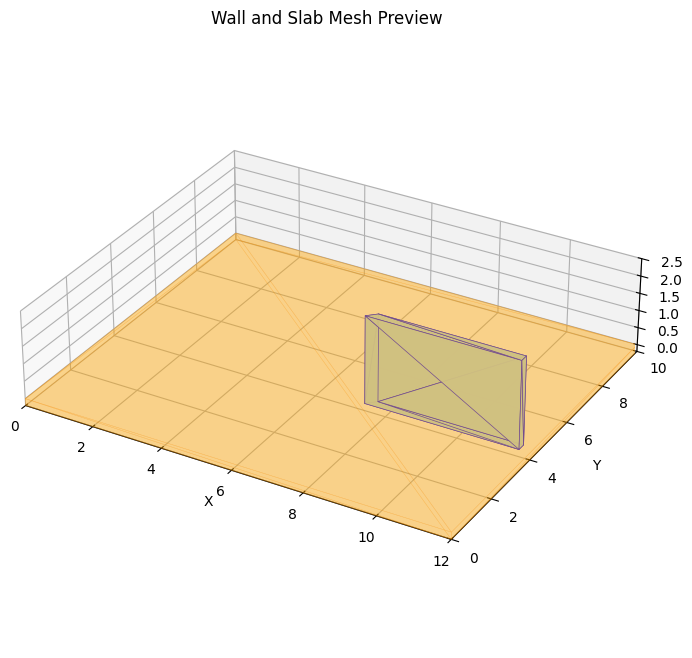

In [101]:
# Extract mesh
def get_mesh(shape):
    verts = np.array(shape.geometry.verts).reshape(-1, 3)
    faces = np.array(shape.geometry.faces).reshape(-1, 3)
    triangles = [verts[f] for f in faces]
    return verts, triangles

wall_verts, wall_tris = get_mesh(wall_shape)
slab_verts, slab_tris = get_mesh(slab_shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Slab first: more transparent
slab_mesh = Poly3DCollection(
    slab_tris,
    alpha=0.25,
    facecolor="orange",
    edgecolor="darkorange",
    linewidth=0.3
)

# Wall second: more opaque
wall_mesh = Poly3DCollection(
    wall_tris,
    alpha=0.95,
    facecolor="lightblue",
    edgecolor="blue",
    linewidth=0.5
)

ax.add_collection3d(slab_mesh)
ax.add_collection3d(wall_mesh)

all_verts = np.vstack([wall_verts, slab_verts])

ax.set_xlim(all_verts[:, 0].min(), all_verts[:, 0].max())
ax.set_ylim(all_verts[:, 1].min(), all_verts[:, 1].max())
ax.set_zlim(all_verts[:, 2].min(), all_verts[:, 2].max())

ax.set_box_aspect([
    max(np.ptp(all_verts[:, 0]), 1e-3),
    max(np.ptp(all_verts[:, 1]), 1e-3),
    max(np.ptp(all_verts[:, 2]), 1e-3)
])

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Wall and Slab Mesh Preview")

plt.show()

## Spatial hierarchy
<a id="spatial-hierarchy"></a>

IFC is structured like:


```
Project
 └── Site
      └── Building
           └── Storey
                └── Elements
```



In [102]:
#Define Data Frame and Relationships

rows = []

for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure

    for e in rel.RelatedElements:
        rows.append({
            "storey": storey.Name,
            "element": e.is_a(),
            "name": e.Name
        })

df_storey = pd.DataFrame(rows)
df_storey.head()

,storey,element,name
0,Erdgeschoss,IfcStair,Wendeltreppe
1,Erdgeschoss,IfcWallStandardCase,Wand-Int-ERDG-4
2,Erdgeschoss,IfcAnnotation,NaN
3,Erdgeschoss,IfcAnnotation,NaN
4,Erdgeschoss,IfcAnnotation,NaN


### Graphs

In addition to tabular and geometric analysis, IFC models can be interpreted as graphs, where building elements are represented as nodes and their relationships as edges.

This graph-based representation enables the explicit visualization and analysis of structural, spatial, and semantic connections within the model. By mapping relationships such as spatial containment (e.g., storey → element) and element interactions (e.g., wall → opening → door), the building can be understood as a network rather than a collection of isolated objects.


```
IFC Relationships Structure

IFC Model
├── Spatial Structure (WHERE)
│   ├── IfcRelAggregates
│   │   └── Project → Site → Building → Storey
│   ├── IfcRelContainedInSpatialStructure
│   │   └── Storey → Elements
│   └── IfcRelReferencedInSpatialStructure
│       └── Secondary spatial references

├── Element Decomposition (PART OF)
│   ├── IfcRelAggregates
│   │   └── Element → Sub-elements
│   └── IfcRelNests
│       └── Element → Components

├── Openings & Hosting (EMBEDDED IN)
│   ├── IfcRelVoidsElement
│   │   └── Wall → Opening
│   └── IfcRelFillsElement
│       └── Opening → Door / Window

├── Properties & Types (DESCRIBED BY)
│   ├── IfcRelDefinesByProperties
│   │   └── Element → Property Sets
│   └── IfcRelDefinesByType
│       └── Element → Type Object

├── Materials & Classification (ASSOCIATED WITH)
│   ├── IfcRelAssociatesMaterial
│   │   └── Element → Material
│   └── IfcRelAssociatesClassification
│       └── Element → Classification System

├── Connectivity (CONNECTED TO)
│   ├── IfcRelConnectsElements
│   ├── IfcRelConnectsPathElements
│   └── IfcRelConnectsStructuralElement
│       └── Element ↔ Element

├── Assignments & Control (MANAGED BY)
│   ├── IfcRelAssignsToGroup
│   ├── IfcRelAssignsToProcess
│   ├── IfcRelAssignsToActor
│   └── IfcRelAssignsToControl
│       └── Element → External context

└── Special / Domain-Specific
    ├── IfcRelCoversBldgElements
    ├── IfcRelServicesBuildings
    ├── IfcRelFlowControlElements
    └── IfcRelInterferesElements
```



In [103]:
G = nx.DiGraph()

def node_label(e):
    return f"{e.is_a()}: {e.Name or e.GlobalId[:8]}"

def add_ifc_node(G, e, group=None):
    G.add_node(
        e.GlobalId,
        label=node_label(e),
        group=group or e.is_a(),
        title=f"""
        Type: {e.is_a()}
        Name: {e.Name}
        GlobalId: {e.GlobalId}
        """
    )

# --------------------------------
# 1. Storey → Walls / Slabs
# --------------------------------
for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure

    if not storey.is_a("IfcBuildingStorey"):
        continue

    add_ifc_node(G, storey, group="IfcBuildingStorey")

    for e in rel.RelatedElements:
        if e.is_a() in {"IfcWall", "IfcWallStandardCase", "IfcSlab"}:
            add_ifc_node(G, e)
            G.add_edge(storey.GlobalId, e.GlobalId, relation="contains")


# --------------------------------
# 2. Wall → Opening
# --------------------------------
for rel in model.by_type("IfcRelVoidsElement"):
    wall = rel.RelatingBuildingElement
    opening = rel.RelatedOpeningElement

    if wall.is_a() in {"IfcWall", "IfcWallStandardCase"}:
        add_ifc_node(G, wall)
        add_ifc_node(G, opening, group="IfcOpeningElement")
        G.add_edge(wall.GlobalId, opening.GlobalId, relation="voids")


# --------------------------------
# 3. Opening → Door / Window
# --------------------------------
for rel in model.by_type("IfcRelFillsElement"):
    opening = rel.RelatingOpeningElement
    element = rel.RelatedBuildingElement

    if element.is_a() in {"IfcDoor", "IfcWindow"}:
        add_ifc_node(G, opening, group="IfcOpeningElement")
        add_ifc_node(G, element)
        G.add_edge(opening.GlobalId, element.GlobalId, relation="fills")


# --------------------------------
# 4. Slab → Beam
# Approximation: connect beams to slabs in same storey
# --------------------------------
storey_elements = {}

for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure

    if not storey.is_a("IfcBuildingStorey"):
        continue

    slabs = [
        e for e in rel.RelatedElements
        if e.is_a() == "IfcSlab"
    ]

    beams = [
        e for e in rel.RelatedElements
        if e.is_a() == "IfcBeam"
    ]

    for slab in slabs:
        add_ifc_node(G, slab)

        for beam in beams:
            add_ifc_node(G, beam)
            G.add_edge(slab.GlobalId, beam.GlobalId, relation="same_storey_structural_relation")


print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 55
Edges: 59


In [104]:
# Design elements as Graphs
G = nx.DiGraph()

allowed = {"IfcWall", "IfcSlab", "IfcDoor", "IfcWindow", "IfcColumn", "IfcBeam"}

for rel in model.by_type("IfcRelContainedInSpatialStructure"):
    storey = rel.RelatingStructure
    storey_id = storey.GlobalId
    storey_label = f"{storey.is_a()}: {storey.Name}"

    G.add_node(
        storey_id,
        label=storey_label,
        group="storey",
        title=storey_label
    )

    for e in rel.RelatedElements:
        if e.is_a() in allowed:
            element_id = e.GlobalId
            element_label = f"{e.is_a()}: {e.Name}"

            G.add_node(
                element_id,
                label=element_label,
                group=e.is_a(),
                title=f"""
                Type: {e.is_a()}
                Name: {e.Name}
                GlobalId: {e.GlobalId}
                """
            )

            G.add_edge(storey_id, element_id)

In [105]:
# Add wall → opening relationships
for rel in model.by_type("IfcRelVoidsElement"):
    wall = rel.RelatingBuildingElement
    opening = rel.RelatedOpeningElement

    if wall and opening:
        G.add_node(
            wall.GlobalId,
            label=f"{wall.is_a()}: {wall.Name}",
            group=wall.is_a(),
            title=f"{wall.is_a()}<br>{wall.Name}<br>{wall.GlobalId}"
        )

        G.add_node(
            opening.GlobalId,
            label=f"{opening.is_a()}: {opening.Name}",
            group="IfcOpeningElement",
            title=f"{opening.is_a()}<br>{opening.Name}<br>{opening.GlobalId}"
        )

        G.add_edge(wall.GlobalId, opening.GlobalId, relation="voids")


# Add opening → door/window relationships
for rel in model.by_type("IfcRelFillsElement"):
    opening = rel.RelatingOpeningElement
    element = rel.RelatedBuildingElement

    if opening and element:
        G.add_node(
            element.GlobalId,
            label=f"{element.is_a()}: {element.Name}",
            group=element.is_a(),
            title=f"{element.is_a()}<br>{element.Name}<br>{element.GlobalId}"
        )

        G.add_edge(opening.GlobalId, element.GlobalId, relation="fills")

In [106]:
# Display Interactive Graph

from tracemalloc import start
from IPython.display import HTML, display


net = Network(
    height="750px",
    width="100%",
    directed=True,
    notebook=True,
    cdn_resources="in_line"
)

net.from_nx(G)

net.show_buttons(filter_=["physics"])
html = net.generate_html()

with open("assets/ifc_graph.html", "w", encoding="utf-8") as f:
    f.write(html)

from IPython.display import IFrame
IFrame(src="assets/ifc_graph.html", width="100%", height=700)

In [107]:
# Download Graph

# # .html
# from google.colab import files
# files.download("ifc_graph.html")

# # .json
# data = json_graph.node_link_data(G)
# with open("ifc_graph.json", "w") as f:
#     json.dump(data, f)

# files.download("ifc_graph.json")


from pathlib import Path
from networkx.readwrite import json_graph
import json

Path("assets").mkdir(exist_ok=True)

# Save graph HTML
html = net.generate_html()
Path("assets/ifc_graph.html").write_text(html, encoding="utf-8")

# Save graph JSON
data = json_graph.node_link_data(G)
Path("assets/ifc_graph.json").write_text(
    json.dumps(data, indent=2),
    encoding="utf-8"
)

print("Saved:")
print("assets/ifc_graph.html")
print("assets/ifc_graph.json")

Saved:
assets/ifc_graph.html
assets/ifc_graph.json


## Classification
<a id="classification"></a>

In [108]:
# Main classes to classify
classes = [
    "IfcWall",
    "IfcSlab",
    "IfcDoor",
    "IfcWindow",
    "IfcColumn",
    "IfcBeam",
    "IfcStair",
    "IfcRamp",
    "IfcRoof",
    "IfcSpace",
]

rows = []

for cls in classes:
    for e in model.by_type(cls):
        psets = ifcopenshell.util.element.get_psets(e)

        rows.append({
            "GlobalId": e.GlobalId,
            "Class": e.is_a(),
            "Name": e.Name,
            "ObjectType": getattr(e, "ObjectType", None),
            "PredefinedType": getattr(e, "PredefinedType", None),

            # Common useful semantic fields
            "IsExternal": (
                psets.get("Pset_WallCommon", {}).get("IsExternal")
                or psets.get("Pset_DoorCommon", {}).get("IsExternal")
                or psets.get("Pset_WindowCommon", {}).get("IsExternal")
                or psets.get("Pset_SlabCommon", {}).get("IsExternal")
            ),
            "LoadBearing": (
                psets.get("Pset_WallCommon", {}).get("LoadBearing")
                or psets.get("Pset_SlabCommon", {}).get("LoadBearing")
                or psets.get("Pset_ColumnCommon", {}).get("LoadBearing")
                or psets.get("Pset_BeamCommon", {}).get("LoadBearing")
            ),
            "FireRating": (
                psets.get("Pset_WallCommon", {}).get("FireRating")
                or psets.get("Pset_DoorCommon", {}).get("FireRating")
                or psets.get("Pset_WindowCommon", {}).get("FireRating")
                or psets.get("Pset_SlabCommon", {}).get("FireRating")
            ),
        })

df_classification = pd.DataFrame(rows)

df_classification.head()

,GlobalId,Class,Name,ObjectType,PredefinedType,IsExternal,LoadBearing,FireRating
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,NaN,None,None,None
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,NaN,None,None,None
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,NaN,None,None,None
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,NaN,None,None,None
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,NaN,None,None,None


In [109]:
# Count by IFC class
df_classification.groupby("Class").size().reset_index(name="count")

,Class,count
0,IfcBeam,4
1,IfcDoor,5
2,IfcSlab,4
3,IfcSpace,7
4,IfcStair,1
5,IfcWallStandardCase,13
6,IfcWindow,11


In [110]:
# Count by class + predefined type
df_classification.groupby(
    ["Class", "PredefinedType"],
    dropna=False
).size().reset_index(name="count")

,Class,PredefinedType,count
0,IfcBeam,NaN,4
1,IfcDoor,NaN,5
2,IfcSlab,BASESLAB,1
3,IfcSlab,FLOOR,1
4,IfcSlab,ROOF,2
5,IfcSpace,NaN,7
6,IfcStair,NaN,1
7,IfcWallStandardCase,NaN,13
8,IfcWindow,NaN,11


In [111]:
# Load-bearing classification
df_classification.groupby(
    ["Class", "LoadBearing"],
    dropna=False
).size().reset_index(name="count")

,Class,LoadBearing,count
0,IfcBeam,NaN,1
1,IfcBeam,True,3
2,IfcDoor,NaN,5
3,IfcSlab,NaN,4
4,IfcSpace,NaN,7
5,IfcStair,NaN,1
6,IfcWallStandardCase,NaN,13
7,IfcWindow,NaN,11


In [112]:
# Export to CSV
df_classification.to_csv("assets/ifc_classification.csv", index=False)

## GIS extraction
<a id="gis-extraction"></a>

In [113]:
# Footprints

# Dataframe (Table)
def element_footprint(element, settings):
    shape = ifcopenshell.geom.create_shape(settings, element)
    verts = np.array(shape.geometry.verts).reshape(-1, 3)
    xy = verts[:, :2]

    return MultiPoint(xy).convex_hull


rows = []

target_classes = ["IfcWall", "IfcSlab", "IfcDoor", "IfcWindow", "IfcColumn"]

for cls in target_classes:
    for e in model.by_type(cls):
        try:
            footprint = element_footprint(e, settings)

            rows.append({
                "GlobalId": e.GlobalId,
                "Class": e.is_a(),
                "Name": e.Name,
                "PredefinedType": getattr(e, "PredefinedType", None),
                "Area_2D": footprint.area,
                "Length_2D": footprint.length,
                "geometry": footprint
            })

        except Exception as err:
            print("Skipped:", e.is_a(), e.Name, err)

df_footprints = pd.DataFrame(rows)
df_footprints.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((7.41 4.01, 7.65 4.25, 11.7 4.25, 11...."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((7.41 4.01, 7.41 9.7, 7.65 9.7, 7.65 ..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((3.8 5.99, 3.8 9.7, 4.04 9.7, 4.04 5...."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((0.3 5.75, 0.3 5.99, 7.41 5.99, 7.41 ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((0.3 4.01, 0.3 4.25, 3.8 4.25, 3.8 4...."


In [114]:
# GeoDataFrame (Georeferenced)
gdf_footprints = gpd.GeoDataFrame(
    df_footprints,
    geometry="geometry",
    crs=None  # IFC local coordinates unless georeferenced
)

gdf_footprints.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((7.41 4.01, 7.65 4.25, 11.7 4.25, 11...."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((7.41 4.01, 7.41 9.7, 7.65 9.7, 7.65 ..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((3.8 5.99, 3.8 9.7, 4.04 9.7, 4.04 5...."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((0.3 5.75, 0.3 5.99, 7.41 5.99, 7.41 ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((0.3 4.01, 0.3 4.25, 3.8 4.25, 3.8 4...."


### Display

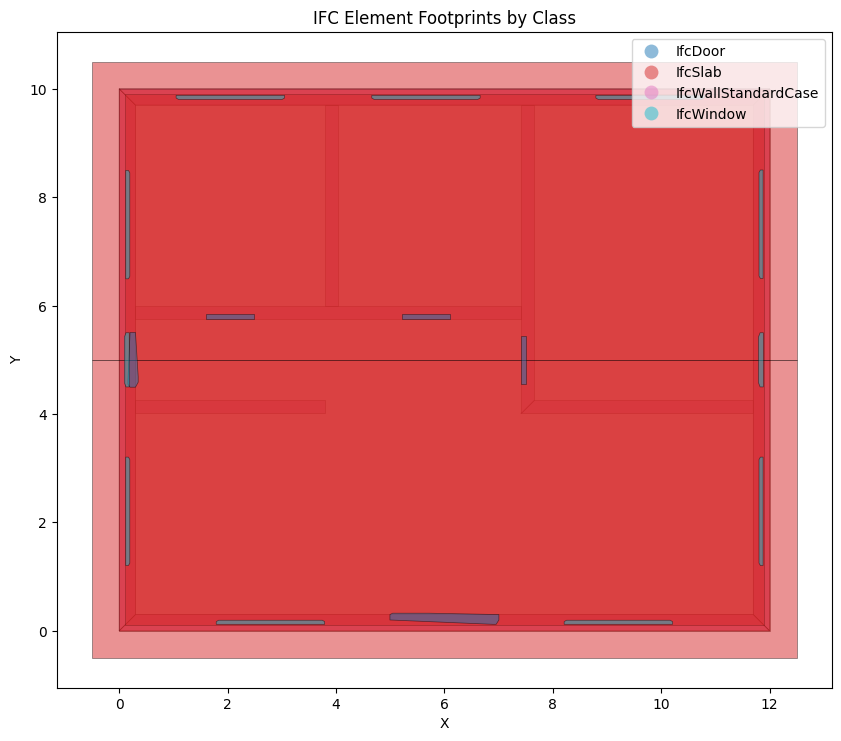

In [115]:
ax = gdf_footprints.plot(
    figsize=(10, 10),
    column="Class",
    legend=True,
    alpha=0.5,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title("IFC Element Footprints by Class")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
plt.show()

In [116]:
# Get IFC site location
site = model.by_type("IfcSite")[0]

print("RefLatitude:", site.RefLatitude)
print("RefLongitude:", site.RefLongitude)

RefLatitude: (49, 6, 1, 566000)
RefLongitude: (8, 26, 11, 540400)


In [117]:
# Convert coordinates to decimals

def ifc_dms_to_decimal(dms):
    """
    IFC stores lat/lon as:
    (degrees, minutes, seconds, millionths_of_seconds)
    """
    if dms is None:
        return None

    deg = dms[0]
    minutes = dms[1] if len(dms) > 1 else 0
    seconds = dms[2] if len(dms) > 2 else 0
    millionths = dms[3] if len(dms) > 3 else 0

    sign = -1 if deg < 0 else 1

    return sign * (
        abs(deg)
        + minutes / 60
        + (seconds + millionths / 1_000_000) / 3600
    )


lat = ifc_dms_to_decimal(site.RefLatitude)
lon = ifc_dms_to_decimal(site.RefLongitude)

print("Latitude:", lat)
print("Longitude:", lon)

Latitude: 49.100435000000004
Longitude: 8.436539


In [118]:
# Approximate georeferencing of Geometry
gdf_geo = gdf_footprints.copy()

gdf_geo["geometry"] = gdf_geo.geometry.translate(
    xoff=lon,
    yoff=lat
)

gdf_geo = gdf_geo.set_crs("EPSG:4326", allow_override=True)

gdf_geo.head()

,GlobalId,Class,Name,PredefinedType,Area_2D,Length_2D,geometry
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,Wand-Int-ERDG-4,NaN,1.0008,8.919411,"POLYGON ((15.84654 53.11044, 16.08654 53.35044..."
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,Wand-Int-ERDG-2,NaN,1.3368,11.719411,"POLYGON ((15.84654 53.11044, 15.84654 58.80044..."
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,Wand-Int-ERDG-1,NaN,0.8904,7.900000,"POLYGON ((12.23654 55.09044, 12.23654 58.80044..."
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,Wand-Int-ERDG-3,NaN,1.7064,14.700000,"POLYGON ((8.73654 54.85044, 8.73654 55.09044, ..."
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,Wand-Int-ERDG-5,NaN,0.8400,7.480000,"POLYGON ((8.73654 53.11044, 8.73654 53.35044, ..."


In [119]:
#Export GeoJSON File
# gdf_geo.to_file("ifc_footprints_georeferenced.geojson", driver="GeoJSON")

# files.download("ifc_footprints_georeferenced.geojson")


from pathlib import Path

Path("assets").mkdir(exist_ok=True)

out = "assets/ifc_footprints_georeferenced.geojson"
gdf_geo.to_file(out, driver="GeoJSON")

print(f"Saved: {out}")

Saved: assets/ifc_footprints_georeferenced.geojson


## Analysis & validation
<a id="analysis-validation"> </a>

One can check:

### Data completeness
- missing names
- missing property sets
- missing quantities
- missing materials
- missing classifications

### Spatial structure
- elements without storey assignment
- broken project / site / building / storey hierarchy
- spaces without boundaries
- elements assigned to the wrong floor

### Geometry quality
- missing geometry
- zero-area or zero-volume elements
- very small or very large elements
- overlapping elements
- duplicated geometry
- objects far away from the model origin

### Semantic consistency
- walls without `IsExternal`
- slabs without `PredefinedType`
- beams/columns without `LoadBearing`
- doors/windows not related to walls
- roofs classified as slabs
- structural elements classified as generic objects

### GIS / georeferencing
- missing CRS
- missing site coordinates
- local coordinates not aligned to map coordinates
- invalid exported GeoJSON geometries

### Exposure modeling
- missing material information
- missing height or floor information
- missing occupancy / space use
- missing structural system hints
- inconsistent external/internal envelope classification

In [120]:
# Walls without IsExternal

for w in model.by_type("IfcWall"):
    p = ifcopenshell.util.element.get_psets(w)

    if "IsExternal" not in p.get("Pset_WallCommon", {}):
        print("Missing IsExternal:", w.GlobalId, w.Name)

Missing IsExternal: 2XPyKWY018sA1ygZKgQPtU Wand-Int-ERDG-4
Missing IsExternal: 3PfS__Y_DBAfq5naM6zD2Z Wand-Int-ERDG-2
Missing IsExternal: 2ptk1k7qn8_Qk22vjh$0DE Wand-Int-ERDG-1
Missing IsExternal: 3jjW3rL656ex34Gws22EfM Wand-Int-ERDG-3
Missing IsExternal: 1$wmdwWPjDYuku_ghVkynE Wand-Int-ERDG-5
Missing IsExternal: 3rPX_Juz59peXXY6wDJl18 Wand-Ext-ERDG-1
Missing IsExternal: 16DNNqzfP2thtfaOflvsKA Wand-Ext-ERDG-4
Missing IsExternal: 25fsbPyk15VvuXI$yNKenK Wand-Ext-ERDG-3
Missing IsExternal: 1bzfVsJqn8De5PukCrqylz Wand-Ext-ERDG-2
Missing IsExternal: 0knNIAVBPBFvBy_m5QVHsU Wand-Ext-OG-1
Missing IsExternal: 25OWQvmXj5BPgyergP43tY Wand-Ext-OG-2
Missing IsExternal: 3VCarUKgH1buLo22Ozxe6J Wand-Ext-OG-3
Missing IsExternal: 3Ttjr$59XEWfWN1WUHjelZ Wand-Ext-OG-4


In [121]:
rows = []

for e in model.by_type("IfcWall"):
    psets = ifcopenshell.util.element.get_psets(e)

    rows.append({
        "id": e.GlobalId,
        "type": e.is_a(),
        "is_external": psets.get("Pset_WallCommon", {}).get("IsExternal"),
        "load_bearing": psets.get("Pset_WallCommon", {}).get("LoadBearing"),
    })

df_exposure = pd.DataFrame(rows)
df_exposure.head()

,id,type,is_external,load_bearing
0,2XPyKWY018sA1ygZKgQPtU,IfcWallStandardCase,None,None
1,3PfS__Y_DBAfq5naM6zD2Z,IfcWallStandardCase,None,None
2,2ptk1k7qn8_Qk22vjh$0DE,IfcWallStandardCase,None,None
3,3jjW3rL656ex34Gws22EfM,IfcWallStandardCase,None,None
4,1$wmdwWPjDYuku_ghVkynE,IfcWallStandardCase,None,None


In [122]:
import os
print(os.getcwd())

c:\Users\ReDI\Documents\GitHub\2026_GREAM\training\20260301-0731_ReDi\mentii\projects\IfcOpenShell\repo\notebooks


In [123]:
from pathlib import Path

ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True)

html_path = ASSETS / "ifc_graph.html
json_path = ASSETS / "ifc_graph.json"

# save html
html = net.generate_html()
html_path.write_text(html, encoding="utf-8")

# save json
from networkx.readwrite import json_graph
import json

data = json_graph.node_link_data(G)
json_path.write_text(json.dumps(data, indent=2), encoding="utf-8")

print(html_path.resolve())

SyntaxError: unterminated string literal (detected at line 6) (1922601302.py, line 6)